# 02 -- The records: look before processing

This workbook builds each site's cache and draws its record, its band coherence, its coherence maps, its
spectra and its spectrograms. Nothing is processed here. What it answers is which channels a site actually
recorded, over which days, and in which state: a reversed magnetic axis, a dead electric line, two lines
carrying one noise, a gain, a turn of the sensor, a rail or a step all show in these five pictures before any
transfer function is estimated.

The cache is the record as laid. Every hourly file is placed on one absolute time axis by its own header
start and never concatenated, so a missing hour stays a gap and does not shift the hours after it; gaps are
NaN; the counts are converted to nT and mV/km by the instrument constants and the site's own dipole lengths.
No sign, no rotation and no notch is applied: the frame and the signs come from `decisions.csv` at processing
time, and a cache carrying them could not be re-read under a different decision.

Four checks state their failure criterion in bold above the cell and print a verdict below it. A check that
scores zero items prints UNJUDGED and counts as a failure. A criterion that is met is reported FAILED and is
not revised afterwards.

The words for the reference kinds are fixed in workbook 01 and used here as words: single station, remote
site, fleet stack, observatory, stack + observatory, member.

In [1]:
# ---- parameters: change these and re-run the workbook ----
SURVEY = "queensland_phase2"  # any folder under surveys/: queensland_phase2 | queensland_phase3 | victoria
SITES = "largest"# "all" | "largest" (the register's largest group) | a group name | ["Q49", "Q50"]
MAX_SITES = 13# 0 = every chosen site; a cap keeps an example short and names what it kept
WORK_ROOT = None              # None = survey.yaml work_root; every cache and figure lands under it
RATES = [1, 10]               # the caches built; 10 is EDL only, and a student short of disk sets [1]
WIN_MIN, STEP_MIN = 60, 30    # the base window and step of figures 02, 03 and 05, in minutes
PMAX = 20000                  # the longest period the level ladder reaches, in s
REBUILD = False               # True rebuilds every cache from the raw files, which is the slow path
SHOW = "first"                # the site whose five figures are shown below; a site name, or "none"


## The survey and the chosen set

Everything below runs on `surveys/<SURVEY>/` and writes under that survey's `work_root`. `SITES` chooses the
set: `all` is every row of sites.csv, `largest` is the largest group of the deployment register workbook 01
wrote, a group name such as `G01` is that group, and a list is the sites it names. A group is the pool the
reference choices are drawn from, so running a workbook over one group is running it over a set of sites that
were recording at the same time.

In [2]:
import time
import warnings
warnings.filterwarnings("ignore")
from datetime import datetime, timezone
from pathlib import Path

# mt_io logs one INFO line per file read, which is thousands of lines per site
from loguru import logger as _loguru
_loguru.disable("mt_io")

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")                   # the figures are written to disk and shown from there, not inline
import matplotlib.pyplot as plt
from IPython.display import Image, display

from auslamp_proc import survey as SV, look
from auslamp_proc.raw import cache
from auslamp_proc.figures import record as FREC, site as FSITE

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 400)

sv = SV.load_survey(SURVEY)
if WORK_ROOT:
    sv.cfg["work_root"] = WORK_ROOT
WORK = Path(sv.cfg["work_root"])
CHOSEN, WHY = SV.select_sites(sv, SITES, MAX_SITES)
WRITTEN = []
TIMING = {}

def site_dir(s):
    d = WORK / s
    d.mkdir(parents=True, exist_ok=True)
    return d

def load(s):
    """The site's 1 Hz cache and its row. One site is held at a time: a 60 d record is 105 MB a channel."""
    t0, arrays, meta = cache.load(s, WORK, 1)
    return t0, arrays, meta, sv.site(s)

def midpoint(t0, n, fs=1.0):
    return datetime.fromtimestamp(t0 + n / fs / 2, timezone.utc)

def show(s, name):
    p = WORK / s / name
    if SHOW != "none" and p.exists() and s == SHOW_SITE:
        display(Image(filename=str(p)))

SHOW_SITE = "" if (SHOW == "none" or not CHOSEN) else (CHOSEN[0] if SHOW == "first" else SHOW)

print("survey       %s" % sv.cfg["name"])
print("work root    %s" % WORK)
print("sites        %d chosen from %s" % (len(CHOSEN), WHY))
print("             %s" % " ".join(CHOSEN))
print("rates        %s Hz" % ", ".join(str(r) for r in RATES))
print("windows      %d min every %d min, periods 2 .. %g s" % (WIN_MIN, STEP_MIN, PMAX))
print("figures of   %s are shown below; every site's five figures are written to <work_root>/<site>/"
      % (SHOW_SITE or "no site"))


survey       queensland_phase2
work root    E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase2
sites        13 chosen from register group G01 (18 members, common window 54.71 d); capped at 13 of 18
             Q82 Q81N Q80N Q79N Q78N Q66N Q67N Q68N Q69N Q58N Q70N Q71N Q59N
rates        1, 10 Hz
windows      60 min every 30 min, periods 2 .. 20000 s
figures of   Q82 are shown below; every site's five figures are written to <work_root>/<site>/


## The sites

The chosen set, with the dipole lengths the electric channels are divided by and the source of each. A cell
reading `assume:<value>` is used and carried into every product's provenance until a sheet replaces it, and is
named as an assumption below. The dipoles matter to the level of every apparent resistivity the survey will
produce: rho scales with the square of the dipole length, so a dipole wrong by 20 per cent moves rho by 44 per
cent.

In [3]:
rows = []
for s in CHOSEN:
    r = sv.site(s)
    dn, kn = cache.dipole_value(r.dipole_n_m)
    de, ke = cache.dipole_value(r.dipole_e_m)
    rows.append(dict(site=s, instrument=r.instrument, sample_rate_hz=r.sample_rate_hz,
                     days=r.days, dipole_n_m=dn, dipole_e_m=de,
                     assumed=" ".join([k for k, v in (("Ex", kn), ("Ey", ke)) if v == "assume"]) or "",
                     dipole_source=str(r.dipole_source)[:70]))
chosen_table = pd.DataFrame(rows)
print(chosen_table.to_string(index=False))
print()
n_assumed = int((chosen_table.assumed != "").sum())
print("%d of %d sites carry an assumed dipole (%s)"
      % (n_assumed, len(chosen_table), ", ".join(chosen_table.site[chosen_table.assumed != ""]) or "none"))
print()
print("the instrument constants the counts are converted by, from survey.yaml")
for inst, k in (sv.cfg.get("instruments") or {}).items():
    print("%s" % inst)
    for key, val in k.items():
        print("   %-14s %s" % (key, val))


site    instrument sample_rate_hz   days  dipole_n_m  dipole_e_m assumed                                                          dipole_source
 Q82 PR6-24+Mag-03           10.0 65.625         9.2         9.4         deployment sheet QLD_AusLAMP_process.xlsx sheet Phase2 transcribed 202
Q81N PR6-24+Mag-03           10.0 65.785        11.0        12.3         deployment sheet QLD_AusLAMP_process.xlsx sheet Phase2 transcribed 202
Q80N PR6-24+Mag-03           10.0 65.635         9.2         9.5         deployment sheet QLD_AusLAMP_process.xlsx sheet Phase2 transcribed 202
Q79N PR6-24+Mag-03           10.0  65.64        11.0        11.0         deployment sheet QLD_AusLAMP_process.xlsx sheet Phase2 transcribed 202
Q78N PR6-24+Mag-03           10.0 65.632        10.9        10.5         deployment sheet QLD_AusLAMP_process.xlsx sheet Phase2 transcribed 202
Q66N PR6-24+Mag-03           10.0 65.769        10.2        10.9         deployment sheet QLD_AusLAMP_process.xlsx sheet Phase2 transcri

## The cache

Each site is built once and then read from disk. The reconciliation below is the placement's own arithmetic:
every file found on disk, every file read, every sample read, every sample written onto the axis, and every
sample written over a value already there. An hour the recorder wrote twice raises `overlap_samples`; an hour
it could not write leaves NaN and lowers nothing, which is why the NaN fraction is a separate column and not
part of the equality.

`auslamp_proc.raw.cache.build` states the criterion in its own docstring, because the check has to be able to
fail: the form in the script this was ported from reads `placed == read or overlap >= 0`, whose right-hand
limb is true at every site, so it passes on a record it has never tested.

**This check fails if, at any site, samples placed differs from samples read, or any two files overlap, or a
channel is more than 50 per cent NaN, or the rate read differs from the rate survey.yaml gives the
instrument.**

In [4]:
recon, prov_all, built = [], {}, []
want_rate = {i: float(b["sample_rate_hz"]) for i, b in sv.cfg["instruments_layout"].items()}
for s in CHOSEN:
    t = time.time()
    row = sv.site(s)
    prov = cache.build(row, sv.cfg, rates=tuple(RATES), force=REBUILD)   # <- REBUILD True re-reads the raw
    TIMING[s] = {"cache_s": round(time.time() - t, 1)}
    prov_all[s] = prov
    built.append("%-9s %6.1f s  %7.3f d  %s" % (s, TIMING[s]["cache_s"], prov["span_days"],
                                                prov["verdict_lines"][-1]))
    recon += cache.reconciliation_row(prov)
    print(built[-1], flush=True)

recon = pd.DataFrame(recon)
print()
print(recon.to_string(index=False))

span = pd.DataFrame([dict(site=s, t0=prov_all[s]["t0_iso"][:16], span_days=prov_all[s]["span_days"],
                          fs_raw=prov_all[s]["fs_raw"], n_1hz=prov_all[s]["n_1hz"],
                          worst_nan=max(prov_all[s]["nan_fraction_1hz"].values()))
                     for s in CHOSEN])
print()
print(span.to_string(index=False))

mismatch = recon[(recon.samples_placed != recon.samples_read) | (recon.overlap_samples > 0)
                 | (recon.files_read != recon.files_found) | (recon.files_unplaced > 0)]
nanny = recon[recon.nan_fraction > 0.5]
rate_bad = [(s, prov_all[s]["fs_raw"], want_rate.get(sv.site(s).instrument))
            for s in CHOSEN if abs(prov_all[s]["fs_raw"] - want_rate.get(sv.site(s).instrument, -1)) > 1e-6]
print()
if not len(recon):
    print("VERDICT: UNJUDGED -- no site was built, so no channel was reconciled")
elif len(mismatch) or len(nanny) or rate_bad:
    print("VERDICT: FAIL -- %d of %d channel rows do not place every sample they read without overlap (%s); "
          "%d channels are more than 50 %% NaN (%s); %d sites read a rate that is not survey.yaml's (%s)"
          % (len(mismatch), len(recon),
             "; ".join("%s %s placed %d of %d, overlap %d" % (r.site, r.channel, r.samples_placed,
                                                              r.samples_read, r.overlap_samples)
                       for r in mismatch.itertuples()) or "none",
             len(nanny), "; ".join("%s %s %.0f %%" % (r.site, r.channel, 100 * r.nan_fraction)
                                   for r in nanny.itertuples()) or "none",
             len(rate_bad), "; ".join("%s %g vs %g Hz" % x for x in rate_bad) or "none"))
else:
    print("VERDICT: PASS -- %d sites, %d channel rows: every sample read was placed (%d in all), no two files "
          "overlap, the worst channel is %.1f %% NaN at %s, and every site reads %s"
          % (len(CHOSEN), len(recon), int(recon.samples_placed.sum()), 100 * recon.nan_fraction.max(),
             recon.site[recon.nan_fraction.idxmax()],
             ", ".join("%g Hz" % v for v in sorted(set(want_rate.values())))))


Q82        303.4 s   65.625 d  reconciliation: PASS -- 5 of 5 channels place every sample they read with no overlap


Q81N       384.2 s   65.785 d  reconciliation: FAIL -- 0 of 5 channels place every sample they read with no overlap


Q80N       357.8 s   65.635 d  reconciliation: PASS -- 5 of 5 channels place every sample they read with no overlap


Q79N       293.8 s   65.640 d  reconciliation: PASS -- 5 of 5 channels place every sample they read with no overlap


Q78N       255.2 s   65.632 d  reconciliation: PASS -- 5 of 5 channels place every sample they read with no overlap


...

Q58N       130.5 s   65.769 d  reconciliation: PASS -- 5 of 5 channels place every sample they read with no overlap


Q70N       143.6 s   65.529 d  reconciliation: PASS -- 5 of 5 channels place every sample they read with no overlap


Q71N       146.8 s   65.648 d  reconciliation: PASS -- 5 of 5 channels place every sample they read with no overlap


Q59N       135.0 s   65.760 d  reconciliation: PASS -- 5 of 5 channels place every sample they read with no overlap



site channel  files_found  files_read  samples_read  samples_placed  overlap_samples  files_unplaced  nan_fraction
 Q82      Hx         1575        1575      56700000        56700000                0               0        0.0000
 Q82      Hy         1575        1575      56700000        56700000                0               0        0.0000
 Q82      Hz         1575        1575      56700000        56700000                0               0        0.0000
 Q82      Ex         1575        1575      56700000        56700000                0               0        0.0000
 Q82      Ey         1575        1575      56700000        56700000                0               0        0.0000
Q81N      Hx         1582        1582      56838670        56838670               70               0        0.0000
Q81N      Hy         1582        1582      56838670        56838670               70               0        0.0000
Q81N      Hz         1582        1582      56838670        56838670            

## The record (figure 01) and the DC field

Figure 01 is the whole 1 Hz record as laid, in eight panels: the five channels as a per-minute mean drawn over
the per-minute range, then H = sqrt(Hx^2 + Hy^2), F = sqrt(Hx^2 + Hy^2 + Hz^2), and the hourly sensor angle
atan2(Hy, Hx). Each magnetic panel carries the IGRF value at the site at the record midpoint and the ratio of
the measured median to it.

What to look for, in this order:

- a reversed axis: Bx below zero, or a panel that is the mirror of its neighbours';
- a dead channel: a flat line, or a range of a few counts where the others move tens of nT;
- a gain: F away from IGRF by more than 5 per cent, with H and Z away by the same factor;
- a turn of the sensor: a step in the hourly angle, which is the mast being knocked or re-laid, and splits the
  record into rotation regimes;
- a rail: a channel pinned at a constant for hours, which is the amplifier at its limit;
- a step: a jump in an electric line, which is an electrode being disturbed.

The table under the figure is the DC test of every chosen site: the medians against IGRF, the three ratios,
the sensor angle, the tilt and the flags. The rules, in the order they fire, are
`|F/F_igrf - 1| > 0.05` a gain or a broken axis; else `|Bz/Z - 1| > 0.10` or `|H/H_igrf - 1| > 0.10` a tilt;
`Bx < 0` a reversed north axis; `|angle| > 30 deg` a sensor laid far from north or the axes exchanged
(`auslamp_proc.look.dc_test`).

The flags are the finding. What the check tests is that the rule fires where the numbers say it must.

**This check fails if any site's F differs from IGRF by more than 5 per cent without a flag naming it, or if
any Bx is negative without a flag.**

Q82         2.6 s  Q82: 65.6 d; median Hx 28340 Hy 44 Hz -45981 nT, H 28340 F 54009 nT, Ex -150.91 Ey 122.79 mV/km, angle +0.1 deg


Q81N        2.4 s  Q81N: 65.8 d; median Hx 27968 Hy -5165 Hz -46326 nT, H 28442 F 54360 nT, Ex 147.00 Ey -927.85 mV/km, angle -10.5 deg


Q80N        2.2 s  Q80N: 65.6 d; median Hx 26964 Hy 849 Hz -47069 nT, H 26978 F 54249 nT, Ex -1222.05 Ey -84.63 mV/km, angle +1.8 deg


Q79N        2.3 s  Q79N: 65.6 d; median Hx 26954 Hy 697 Hz -46964 nT, H 26963 F 54153 nT, Ex -68.27 Ey 354.86 mV/km, angle +1.5 deg


Q78N        2.2 s  Q78N: 65.6 d; median Hx 28256 Hy 942 Hz -46905 nT, H 28273 F 54767 nT, Ex 1806.98 Ey 295.29 mV/km, angle +1.9 deg


...

Q58N        2.3 s  Q58N: 65.8 d; median Hx 28178 Hy 1736 Hz -44936 nT, H 28231 F 53065 nT, Ex 1770.05 Ey 2801.47 mV/km, angle +3.5 deg


Q70N        2.4 s  Q70N: 65.5 d; median Hx 25336 Hy -892 Hz -42547 nT, H 25352 F 49525 nT, Ex -273.50 Ey -621.94 mV/km, angle -2.0 deg


Q71N        2.4 s  Q71N: 65.6 d; median Hx 30383 Hy -886 Hz -49409 nT, H 30784 F 57992 nT, Ex -2532.20 Ey 572.90 mV/km, angle -1.7 deg


Q59N        2.4 s  Q59N: 65.8 d; median Hx 28920 Hy -985 Hz -43571 nT, H 28935 F 52292 nT, Ex 746.87 Ey 611.20 mV/km, angle -1.9 deg



site  days      Bx      By       Bz       H       F  igrf_X  igrf_Y   igrf_Z  igrf_H  igrf_F  Bx_over_X  Bz_over_Z  H_over_Higrf  F_over_Figrf  angle_deg  tilt_deg                                flags verdict
 Q82 65.62 28339.5    43.7 -45980.9 28339.5 54012.7 27532.0  4380.2 -46773.7 27878.3 54451.6     1.0293     0.9831        1.0165        0.9919       0.09      0.85                                         PASS
Q81N 65.79 27967.6 -5165.4 -46326.2 28440.6 54359.7 27452.9  4224.8 -47086.5 27776.0 54668.5     1.0187     0.9839        1.0239        0.9944     -10.46      1.01                                         PASS
Q80N 65.63 26963.8   848.7 -47069.3 26977.1 54252.0 27553.5  4040.0 -47096.2 27848.1 54713.5     0.9786     0.9994        0.9687        0.9916       1.80     -0.78                                         PASS
Q79N 65.64 26953.5   696.9 -46964.3 26962.5 54153.7 27711.2  3878.2 -46972.1 27981.2 54674.7     0.9727     0.9998        0.9636        0.9905       1.48     -0.92

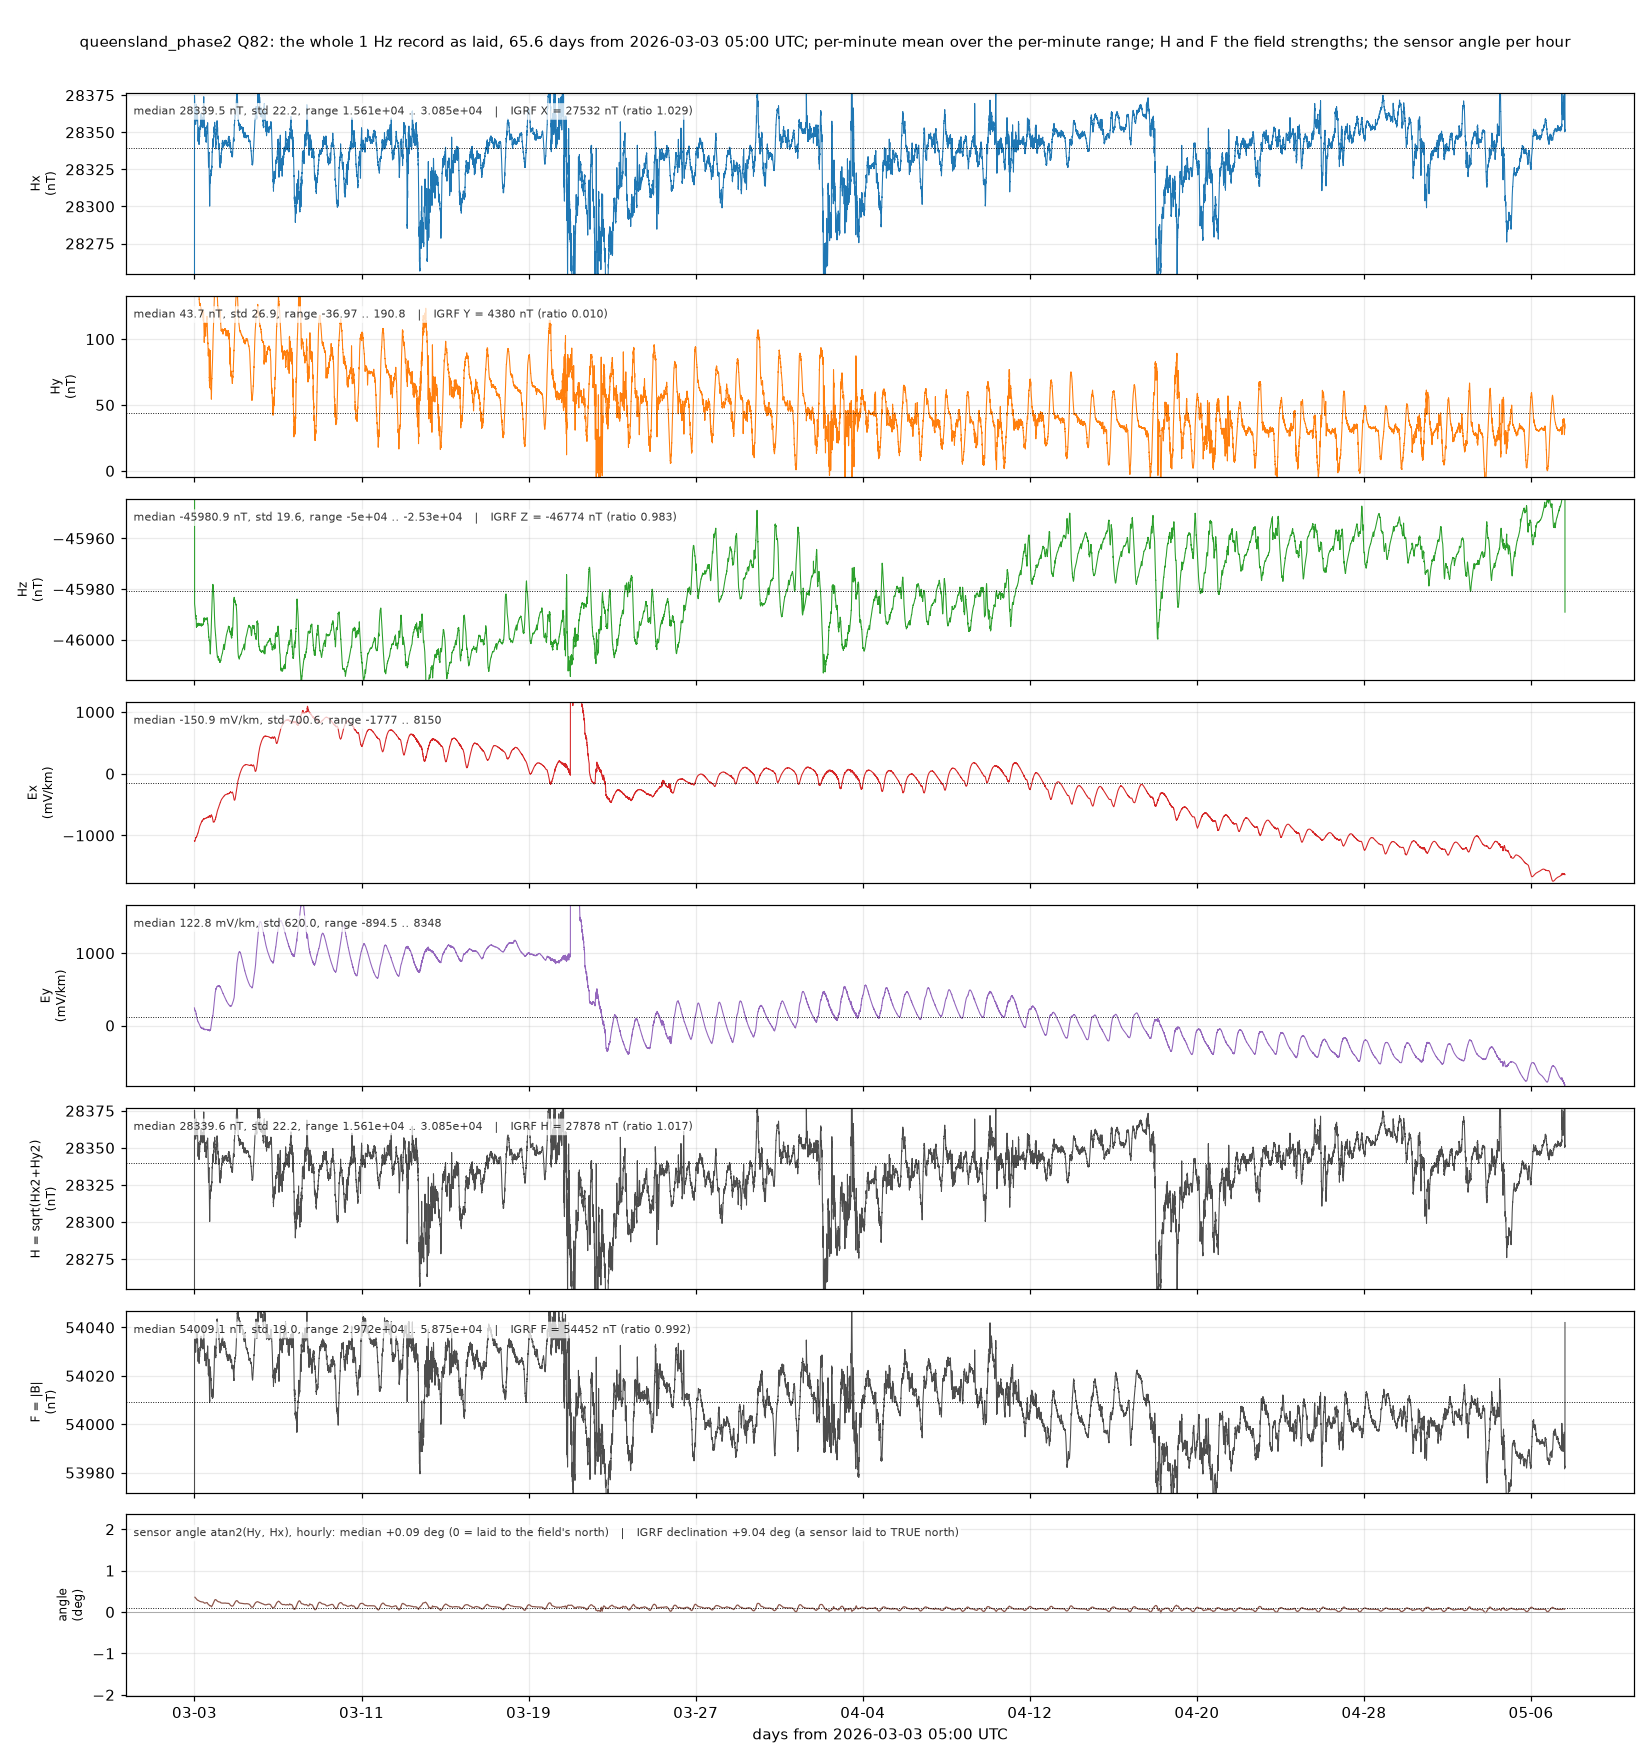


2 of 13 sites carry a flag: Q70N [F/Figrf 0.92 (gain or a broken axis)]; Q71N [F/Figrf 1.08 (gain or a broken axis)]

VERDICT: PASS -- all 13 sites scored; the 2 sites over 5 % in F (Q70N, Q71N) and the 0 with Bx below zero (none) each carry the flag the rule fires, and the largest F/F_igrf departure is 8.1 % at Q71N


In [5]:
dc_rows = []
for s in CHOSEN:
    t = time.time()
    t0, arrays, meta, row = load(s)
    n = len(arrays["Hx"])
    fig, line = FREC.record(t0, arrays, site_dir(s) / "01_record.png", site=s, survey=sv.cfg["name"],
                            lat=float(row.lat), lon=float(row.lon), elev_m=float(row.elev_m), fs=1.0)
    plt.close(fig)
    WRITTEN.append(site_dir(s) / "01_record.png")
    d = look.dc_test(arrays, float(row.lat), float(row.lon), float(row.elev_m), midpoint(t0, n))
    d["site"] = s
    d["days"] = round(n / 86400.0, 2)
    dc_rows.append(d)
    pd.DataFrame([d]).to_csv(site_dir(s) / "dc.csv", index=False)
    WRITTEN.append(site_dir(s) / "dc.csv")
    TIMING[s]["record_s"] = round(time.time() - t, 1)
    del arrays
    print("%-9s %5.1f s  %s" % (s, TIMING[s]["record_s"], line), flush=True)

dc = pd.DataFrame(dc_rows)[["site", "days", "Bx", "By", "Bz", "H", "F", "igrf_X", "igrf_Y", "igrf_Z",
                            "igrf_H", "igrf_F", "Bx_over_X", "Bz_over_Z", "H_over_Higrf", "F_over_Figrf",
                            "angle_deg", "tilt_deg", "flags", "verdict"]]
print()
print(dc.to_string(index=False))
show(SHOW_SITE, "01_record.png")

f_off = dc[(dc.F_over_Figrf - 1).abs() > 0.05]
# dc["flags"], not dc.flags: a DataFrame already carries a `flags` attribute of its own
f_unflagged = f_off[~f_off["flags"].str.contains("F/Figrf", na=False)]
bx_neg = dc[dc.Bx < 0]
bx_unflagged = bx_neg[~bx_neg["flags"].str.contains("Bx negative", na=False)]
print()
print("%d of %d sites carry a flag: %s"
      % (int((dc["flags"] != "").sum()), len(dc),
         "; ".join("%s [%s]" % (r.site, r.flags) for r in dc.itertuples() if r.flags) or "none"))
print()
if not len(dc):
    print("VERDICT: UNJUDGED -- no site was read, so no DC field was scored")
elif len(f_unflagged) or len(bx_unflagged):
    print("VERDICT: FAIL -- %d of %d sites are more than 5 %% off IGRF in F with no flag naming it (%s); "
          "%d sites have Bx below zero with no flag (%s)"
          % (len(f_unflagged), len(dc), ", ".join(f_unflagged.site) or "none",
             len(bx_unflagged), ", ".join(bx_unflagged.site) or "none"))
else:
    print("VERDICT: PASS -- all %d sites scored; the %d sites over 5 %% in F (%s) and the %d with Bx below "
          "zero (%s) each carry the flag the rule fires, and the largest F/F_igrf departure is %.1f %% at %s"
          % (len(dc), len(f_off), ", ".join(f_off.site) or "none", len(bx_neg),
             ", ".join(bx_neg.site) or "none", 100 * (dc.F_over_Figrf - 1).abs().max(),
             dc.site[(dc.F_over_Figrf - 1).abs().idxmax()]))


## Band coherence (figure 02) and the electric lines

Figure 02 is the squared coherence of four pairs against time, one line per band (5-20, 20-200, 100-1000 and
1000-10000 s) on a 12 h running median. How to read them:

| pair | what it is |
|---|---|
| Bx-Ey and By-Ex | the impedance pairs: this is the coherence the transfer function is estimated from |
| Bx-By | the polarisation of the source: a stretch where it rises to one is a single-polarisation event, and a tensor cannot be resolved there |
| Ex-Ey | the two electric lines against each other: high with Bx-By low is common-mode electric noise, the shared electrode of the L array carrying one signal into both lines |

The table under it is the per-UTC-day state of each line: the 20-200 s coherence of Ex with the site's own Hy
and of Ey with its Hx, of Ex with Ey, and the standard deviation of each line after a 3,000 s high-pass, with
the state `dead` (high-passed std under 0.2 mV/km), `sound` (coherence with H at least 0.4 and Ex-Ey under
0.5), `common` (Ex-Ey at least 0.6 and coherence with H under 0.3) or `weak` (`auslamp_proc.look.elines`).
Every series is despiked before the high-pass: one logger spike inside one Welch segment otherwise puts a
whole day's coherence at zero. A day in which any of the four channels is under 80 per cent finite is scored
`gap` and is not a scored day.

Figure 03's coherence maps are computed in the same pass and written with figure 02, because the band lines
are the same numbers averaged over a band.

**This check fails if the state machine is UNJUDGED at any site, that is if no day was scored.**

Q82        87.1 s  days  66 scored  66 | Ex sound 0.82 common 0.04 dead 0.00 | Ey sound 0.80 common 0.04 dead 0.00


Q81N       85.4 s  days  66 scored  66 | Ex sound 1.00 common 0.00 dead 0.00 | Ey sound 1.00 common 0.00 dead 0.00


Q80N       86.1 s  days  66 scored  65 | Ex sound 0.98 common 0.00 dead 0.00 | Ey sound 0.95 common 0.00 dead 0.00


Q79N       85.8 s  days  66 scored  66 | Ex sound 0.97 common 0.01 dead 0.00 | Ey sound 0.95 common 0.01 dead 0.00


Q78N       85.9 s  days  66 scored  66 | Ex sound 0.88 common 0.04 dead 0.00 | Ey sound 0.83 common 0.04 dead 0.00


...

Q58N       89.4 s  days  66 scored  65 | Ex sound 0.00 common 0.79 dead 0.00 | Ey sound 0.00 common 0.79 dead 0.00


Q70N       87.0 s  days  66 scored  66 | Ex sound 0.86 common 0.00 dead 0.00 | Ey sound 0.91 common 0.00 dead 0.00


Q71N       86.5 s  days  66 scored  66 | Ex sound 0.88 common 0.01 dead 0.00 | Ey sound 0.41 common 0.01 dead 0.00


Q59N       87.4 s  days  66 scored  65 | Ex sound 0.28 common 0.34 dead 0.00 | Ey sound 0.31 common 0.34 dead 0.00



site  days_total  days_scored  Ex_sound  Ex_weak  Ex_common  Ex_dead  Ex_gap  Ey_sound  Ey_weak  Ey_common  Ey_dead  Ey_gap  Ex_sound_frac  Ey_sound_frac  both_sound_frac  Ex_longest_sound_run_d  Ey_longest_sound_run_d gap_channels
 Q82          66           66        54        9          3        0       0        53       10          3        0       0          0.818          0.803            0.758                      24                      34             
Q81N          66           66        66        0          0        0       0        66        0          0        0       0          1.000          1.000            1.000                      66                      66             
Q80N          66           65        64        1          0        0       1        62        3          0        0       1          0.985          0.954            0.938                      41                      47         Hx:1
Q79N          66           66        64        1          1        0   

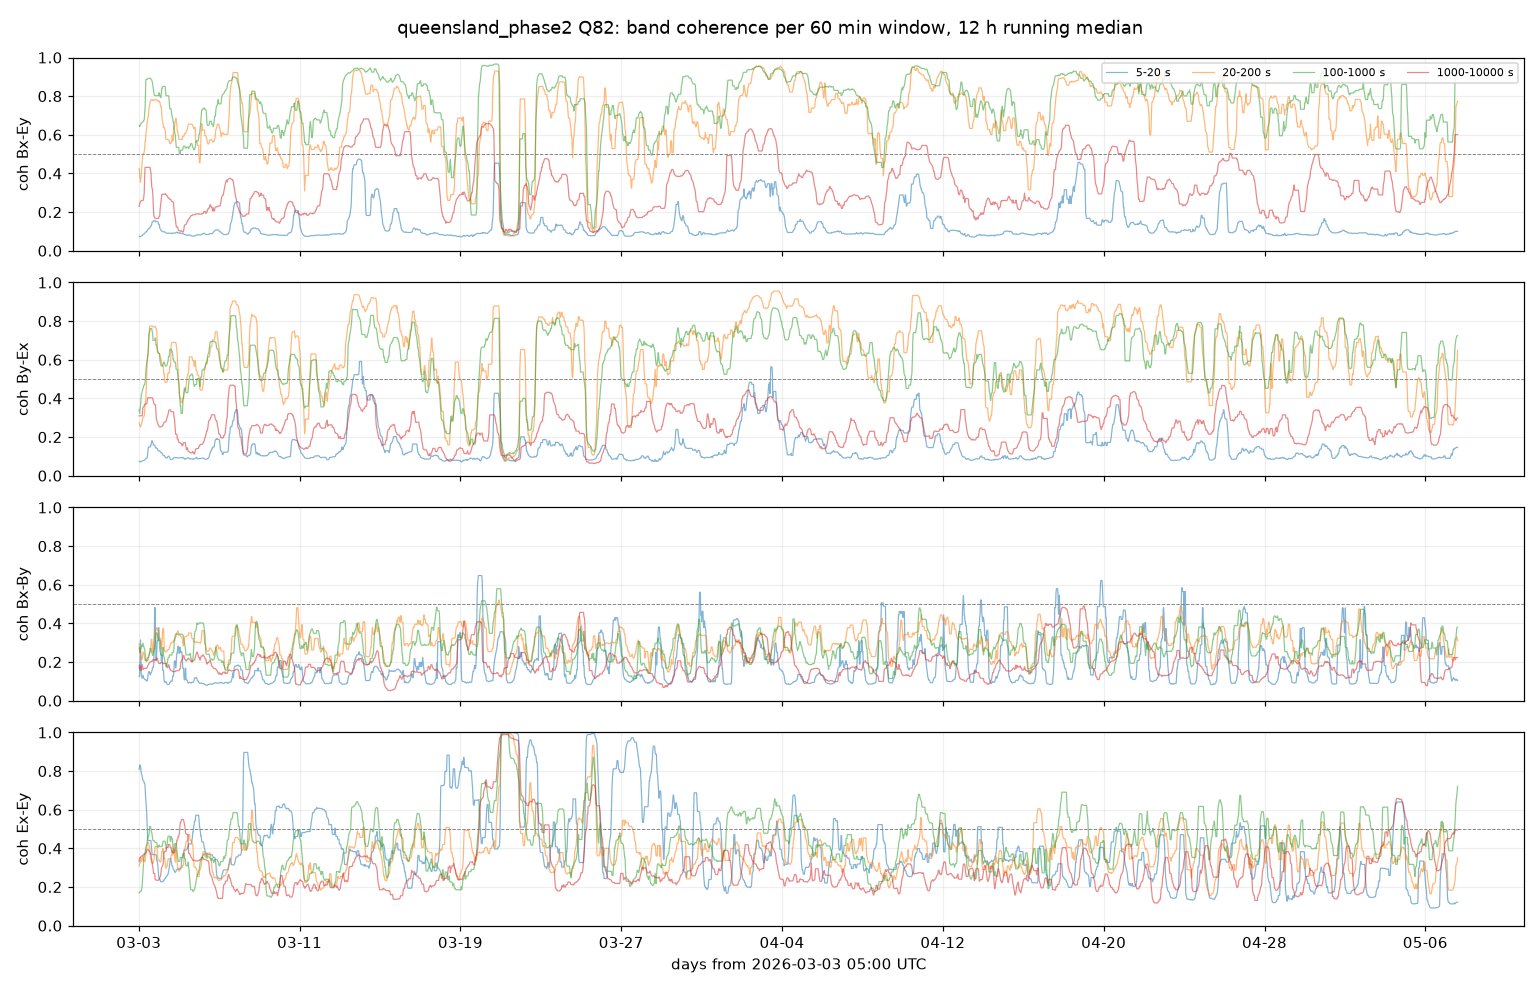


VERDICT: PASS -- every one of the 13 sites scored at least one day, the thinnest being 42 days at Q67N; 9 sites have a line sound on more than half their days and 1 have a line common-mode on more than half


In [6]:
e_rows, band_rows = [], []
for s in CHOSEN:
    t = time.time()
    t0, arrays, meta, row = load(s)
    n = len(arrays["Hx"])
    el = look.elines(t0, arrays, fs=1.0)
    el.to_csv(site_dir(s) / "elines.csv", index=False)
    WRITTEN.append(site_dir(s) / "elines.csv")
    fig, maps = FSITE.coherence_maps(
        t0, arrays, site_dir(s) / "03_coherence_maps.png", fs=1.0,
        win_s=WIN_MIN * 60, step_s=STEP_MIN * 60, pmax=PMAX,          # <- WIN_MIN, STEP_MIN, PMAX
        title="%s %s: squared coherence, %d min windows every %d min, %g h running median"
              % (sv.cfg["name"], s, WIN_MIN, STEP_MIN, FSITE.SMOOTH_H))
    plt.close(fig)
    fig = FSITE.coherence_bands(t0, maps, site_dir(s) / "02_coherence_bands.png", n, fs=1.0,
                                step_s=STEP_MIN * 60, win_min=WIN_MIN,
                                title="%s %s: band coherence per %d min window, %g h running median"
                                      % (sv.cfg["name"], s, WIN_MIN, FSITE.LINE_SMOOTH_H))
    plt.close(fig)
    WRITTEN += [site_dir(s) / "02_coherence_bands.png", site_dir(s) / "03_coherence_maps.png"]
    bt = FSITE.band_table(maps)
    for pair, r in bt.iterrows():
        band_rows.append(dict(site=s, pair=pair, **{c: r[c] for c in bt.columns}))
    e_rows.append(look.eline_summary(el, s))
    TIMING[s]["coherence_s"] = round(time.time() - t, 1)
    del arrays, maps
    su = e_rows[-1]
    print("%-9s %5.1f s  days %3d scored %3d | Ex sound %.2f common %.2f dead %.2f | Ey sound %.2f "
          "common %.2f dead %.2f" % (s, TIMING[s]["coherence_s"], su["days_total"], su["days_scored"],
                                     su["Ex_sound_frac"], su["Ex_common_frac"], su["Ex_dead_frac"],
                                     su["Ey_sound_frac"], su["Ey_common_frac"], su["Ey_dead_frac"]),
          flush=True)

esum = pd.DataFrame(e_rows)
print()
print(esum[["site", "days_total", "days_scored",
            "Ex_sound", "Ex_weak", "Ex_common", "Ex_dead", "Ex_gap",
            "Ey_sound", "Ey_weak", "Ey_common", "Ey_dead", "Ey_gap",
            "Ex_sound_frac", "Ey_sound_frac", "both_sound_frac",
            "Ex_longest_sound_run_d", "Ey_longest_sound_run_d", "gap_channels"]].to_string(index=False))
print()
print("gap_channels counts the days a channel was under 80 %% finite after the despike; a magnetic channel "
      "there is a spiky sensor, not an outage, and is read from the record figure")
print()
if SHOW_SITE and (WORK / SHOW_SITE / "elines.csv").exists():
    print("the day table of %s (the same table is written to every site's elines.csv)" % SHOW_SITE)
    print(pd.read_csv(WORK / SHOW_SITE / "elines.csv").to_string(index=False))
print()
print("median band coherence per pair over the record, 20-200 s")
bandt = pd.DataFrame(band_rows)
print(bandt.pivot(index="site", columns="pair", values="20-200 s").to_string())
print()
print("median band coherence per pair over the record, 100-1000 s")
print(bandt.pivot(index="site", columns="pair", values="100-1000 s").to_string())
show(SHOW_SITE, "02_coherence_bands.png")

unjudged = esum[esum.days_scored == 0]
print()
if not len(esum):
    print("VERDICT: UNJUDGED -- no site was scored at all")
elif len(unjudged):
    print("VERDICT: FAIL -- the state machine scored no day at %d of %d sites (%s)"
          % (len(unjudged), len(esum),
             "; ".join("%s, refused on %s" % (r.site, r.gap_channels or "no channel named")
                       for r in unjudged.itertuples())))
else:
    print("VERDICT: PASS -- every one of the %d sites scored at least one day, the thinnest being %d days at "
          "%s; %d sites have a line sound on more than half their days and %d have a line common-mode on more "
          "than half" % (len(esum), int(esum.days_scored.min()), esum.site[esum.days_scored.idxmin()],
                         int(((esum.Ex_sound_frac > 0.5) | (esum.Ey_sound_frac > 0.5)).sum()),
                         int(((esum.Ex_common_frac > 0.5) | (esum.Ey_common_frac > 0.5)).sum())))


## Coherence maps (figure 03)

The same coherence as figure 02, drawn as squared coherence against time and period rather than averaged into
four bands. The ladder below is how the map reaches 20,000 s from 60 min windows: the base level takes the
largest power of two leaving 4 segments in the window, and each level above it covers a factor of 4 in period
with a segment as long as its longest period, a window of 6 segments and a step of half a segment. Every level
is drawn on the base level's time grid, so the long-period rows are the same value repeated over the hours
their window covers, which is what makes the top of the map look blocky.

What the map shows that the band lines do not:

- a live line is bright from a few tens of seconds to thousands, and the brightness moves with the source: it
  dims at quiet local night and brightens in a storm;
- a dead line is dark at every period at every hour, and stays dark through a storm that lights its neighbour;
- a polarised stretch is a bright band in Bx-By over the same hours that Bx-Ey or By-Ex goes dark: the source
  was one polarisation, so one of the two impedance pairs had nothing to work with;
- common-mode noise is bright in Ex-Ey and dark in both impedance pairs at the same hours.

the level ladder at 1 Hz with 60 min windows every 30 min, to 20000 s
 level  nperseg  segment_s  window_s  step_s  period_floor_s  period_ceiling_s
     0      512      512.0      3600    1800             2.0             512.0
     1     2048     2048.0     12288    1800           512.0            2048.0
     2     8192     8192.0     49152    4096          2048.0            8192.0
     3    32768    32768.0    196608   16384          8192.0           20000.0

4 levels; 8 log bins per decade; the DC bin is dropped and a bin holding no FFT harmonic is dropped
guide lines at 20, 200, 1000, 10000 s; the maps carry a 3 h running median along time and the band lines 12 h

13 of 13 sites have a coherence map on disk


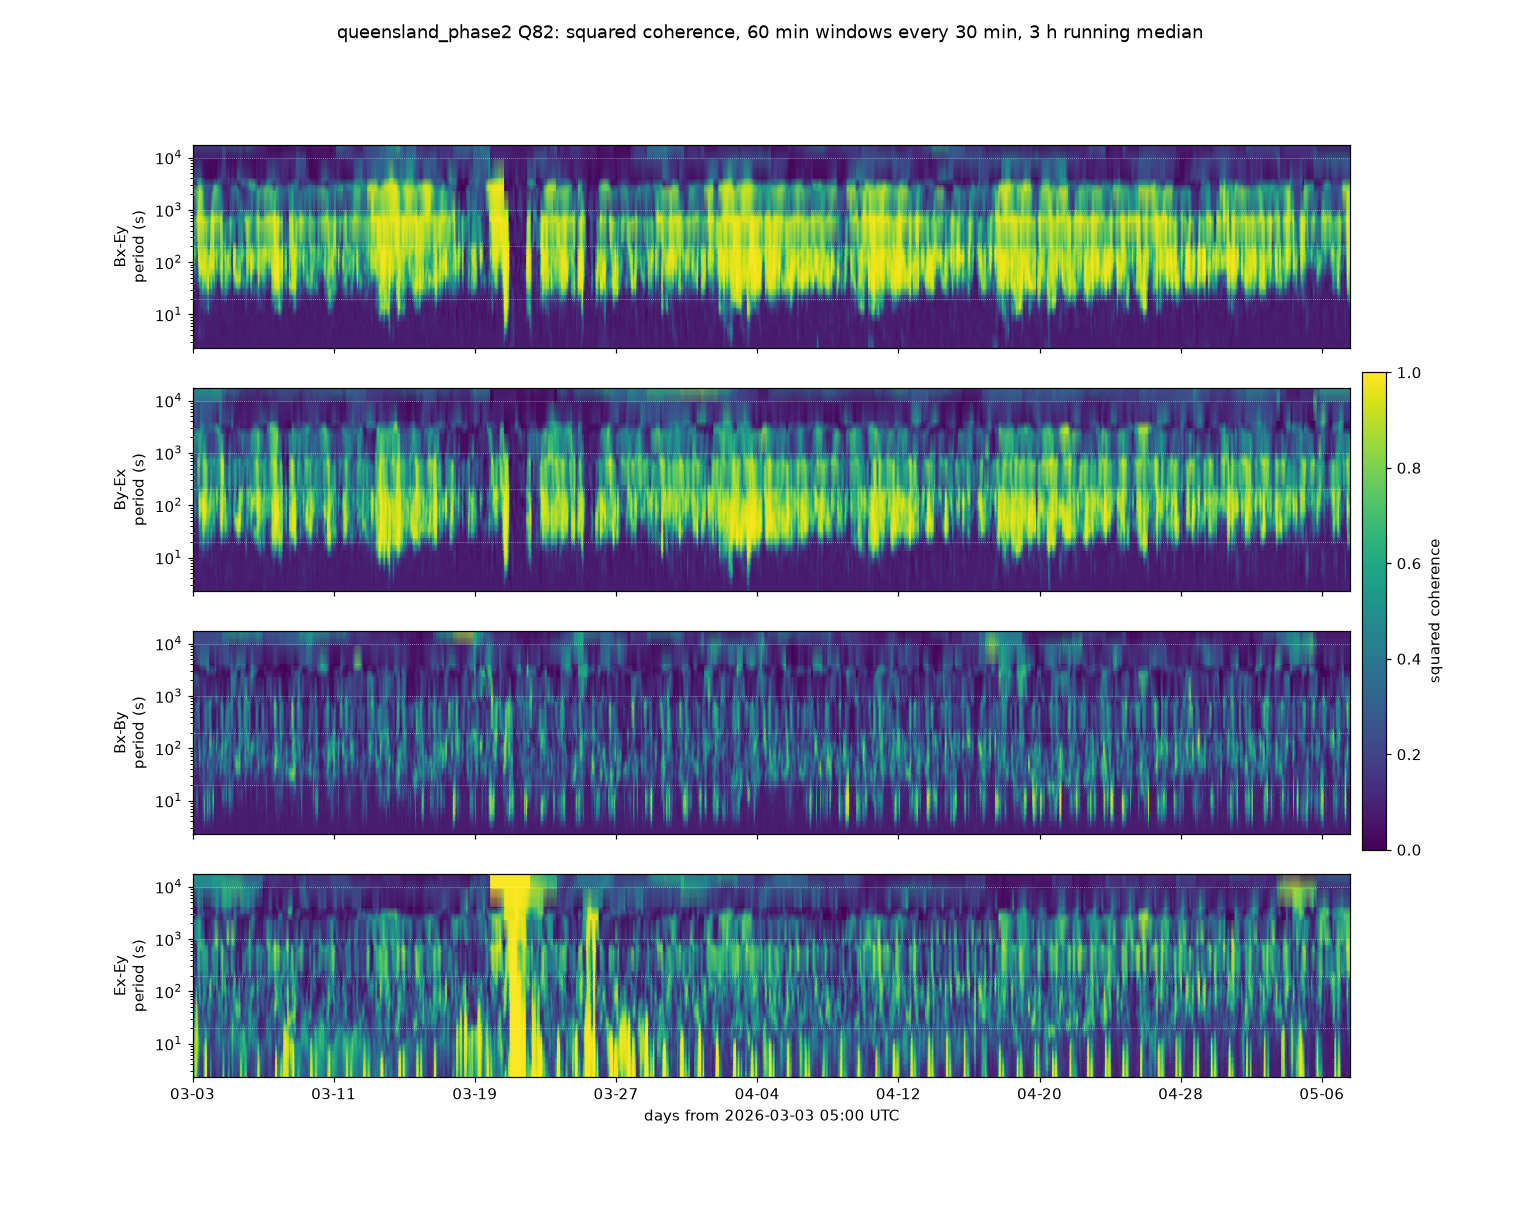

In [7]:
ladder = FSITE.levels_plan(1.0, WIN_MIN * 60, STEP_MIN * 60, pmax=PMAX)
print("the level ladder at 1 Hz with %d min windows every %d min, to %g s" % (WIN_MIN, STEP_MIN, PMAX))
print(ladder.to_string(index=False))
print()
print("%d levels; %d log bins per decade; the DC bin is dropped and a bin holding no FFT harmonic is dropped"
      % (len(ladder), FSITE.PER_DECADE))
print("guide lines at %s s; the maps carry a %g h running median along time and the band lines %g h"
      % (", ".join(str(g) for g in FSITE.GUIDE_S), FSITE.SMOOTH_H, FSITE.LINE_SMOOTH_H))
print()
have3 = [s for s in CHOSEN if (WORK / s / "03_coherence_maps.png").exists()]
print("%d of %d sites have a coherence map on disk" % (len(have3), len(CHOSEN)))
show(SHOW_SITE, "03_coherence_maps.png")


## Spectra (figure 04)

One Welch spectrum per channel over the longest finite run of the record, 4,096-sample segments, the DC bin
dropped, on log-log axes with the 10-1000 s band shaded: that is where a 1 Hz fluxgate does its work and where
the transfer function will be read.

This section is a reading, not a check. A sound electric line falls 4.6-5.6 decades over 1 mHz to 3 Hz; a flat spectrum, under 1 decade of fall over that span, is an open input, an electrode
that is not connected to the ground. On a 1 Hz cache 3 Hz is above the Nyquist frequency, so the fall is
measured to 0.4 Hz instead and the band used is printed with the numbers; the bound 1 decade still separates a
line that falls from one that does not.

decades of fall over 1 mHz - 0.4 Hz
channel    Ex    Ey    Hx    Hy    Hz
site                                 
Q58N     3.94  3.96  4.68  4.80  4.86
Q59N     3.84  3.53  4.27  4.55  4.24
Q66N     2.84  2.59  3.11  3.04  3.63
Q67N     4.34  4.56  4.86  5.10  4.85
Q68N     6.01  4.73  6.33  6.18  4.72
Q69N     5.00  5.19  6.23  6.00  4.71
Q70N     4.02  4.37  2.72  2.45  2.15
Q71N     3.68  3.68  3.01  5.53  4.87
Q78N     3.77  4.00  1.62  2.99  1.78
Q79N     5.94  6.10  6.38  6.44  4.97
Q80N     5.36  5.54  5.11  3.53  3.56
Q81N     0.86  1.46  1.88  0.99  1.34
Q82      4.80  4.88  6.21  6.63  4.44

electric lines falling less than 1 decade (an open input, read and not scored): Q81N Ex 0.86


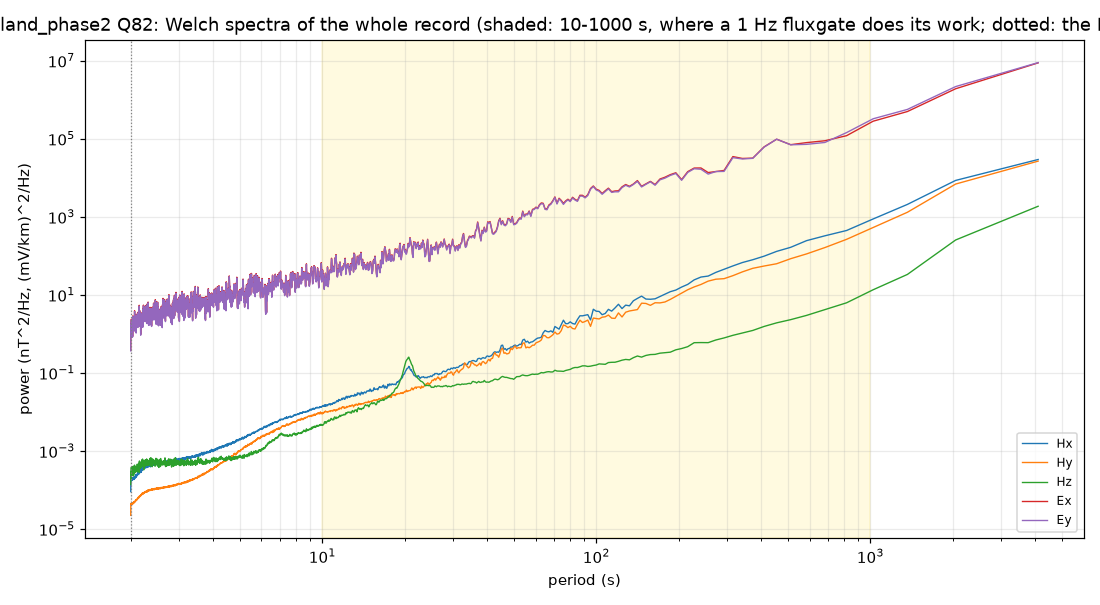

In [8]:
fall_rows = []
for s in CHOSEN:
    t = time.time()
    t0, arrays, meta, row = load(s)
    fig, fall = FSITE.spectra(arrays, site_dir(s) / "04_spectra.png", fs=1.0,
                              title="%s %s: Welch spectra of the whole record (shaded: 10-1000 s, where a "
                                    "1 Hz fluxgate does its work; dotted: the Nyquist period)"
                                    % (sv.cfg["name"], s))
    plt.close(fig)
    WRITTEN.append(site_dir(s) / "04_spectra.png")
    for ch, r in fall.iterrows():
        fall_rows.append(dict(site=s, channel=ch, decades_of_fall=r.decades_of_fall,
                              power_at_100s=r.power_at_100s, band=r.fall_band))
    TIMING[s]["spectra_s"] = round(time.time() - t, 1)
    del arrays

fallt = pd.DataFrame(fall_rows)
wide = fallt.pivot(index="site", columns="channel", values="decades_of_fall")
print("decades of fall over %s" % fallt.band.iloc[0])
print(wide.to_string())
print()
flat = fallt[(fallt.channel.isin(["Ex", "Ey"])) & (fallt.decades_of_fall < 1.0)]
print("electric lines falling less than 1 decade (an open input, read and not scored): %s"
      % ("; ".join("%s %s %.2f" % (r.site, r.channel, r.decades_of_fall) for r in flat.itertuples())
         or "none"))
show(SHOW_SITE, "04_spectra.png")


## Spectrograms (figure 05)

The power of each channel against time and period, in dB of absolute power density, with the colour limits at
that channel's own 2nd and 98th percentile, so a dead stretch is a dark band at every period and a storm is
bright across the whole picture. The table under it reads the base level of the same maps: the median power in
the 20-200 s band, and the fraction of windows more than 10 dB below it (an hour the channel was quiet or
dead) or above it (a burst).

A channel whose `windows 10 dB below` is a large fraction died part way through the record, and the days it
died are what the mask in workbook 05 will cut.

Q82        33.6 s  Hx -1.6 dB Hy -4.1 dB Hz -16.2 dB Ex 6.3 dB Ey 7.0 dB


Q81N       33.3 s  Hx 1.2 dB Hy -3.9 dB Hz -4.9 dB Ex 9.8 dB Ey 12.7 dB


Q80N       33.8 s  Hx -0.6 dB Hy -4.0 dB Hz -8.7 dB Ex 0.8 dB Ey 2.5 dB


Q79N       33.5 s  Hx -1.0 dB Hy -3.7 dB Hz -14.2 dB Ex -0.2 dB Ey 0.2 dB


Q78N       34.3 s  Hx -1.1 dB Hy -2.8 dB Hz -13.8 dB Ex 0.4 dB Ey 2.1 dB


...

Q58N       34.8 s  Hx -2.2 dB Hy -5.1 dB Hz -11.2 dB Ex 32.5 dB Ey 30.1 dB


Q70N       33.9 s  Hx -2.0 dB Hy 0.6 dB Hz 5.0 dB Ex 1.8 dB Ey 3.7 dB


Q71N       33.5 s  Hx 24.4 dB Hy -4.9 dB Hz -16.2 dB Ex 6.6 dB Ey 10.9 dB


Q59N       34.1 s  Hx -0.9 dB Hy -4.3 dB Hz -6.9 dB Ex 16.7 dB Ey 7.9 dB



median power at 20-200 s (dB)
channel    Ex    Ey    Hx   Hy    Hz
site                                
Q58N     32.5  30.1  -2.2 -5.1 -11.2
Q59N     16.7   7.9  -0.9 -4.3  -6.9
Q66N     30.9  29.8  -0.4 -2.9 -12.6
Q67N     40.3  -inf   8.0 -3.1   0.6
Q68N      0.4   4.4  -2.3 -4.6 -15.8
Q69N      3.2   5.5  -1.8 -5.1 -15.4
Q70N      1.8   3.7  -2.0  0.6   5.0
Q71N      6.6  10.9  24.4 -4.9 -16.2
Q78N      0.4   2.1  -1.1 -2.8 -13.8
Q79N     -0.2   0.2  -1.0 -3.7 -14.2
Q80N      0.8   2.5  -0.6 -4.0  -8.7
Q81N      9.8  12.7   1.2 -3.9  -4.9
Q82       6.3   7.0  -1.6 -4.1 -16.2

fraction of windows 10 dB below the median at 20-200 s
channel     Ex     Ey     Hx     Hy     Hz
site                                      
Q58N     0.189  0.186  0.051  0.081  0.000
Q59N     0.264  0.070  0.062  0.082  0.161
Q66N     0.072  0.277  0.040  0.073  0.000
Q67N     0.367  0.000  0.235  0.073  0.211
Q68N     0.047  0.076  0.051  0.076  0.000
Q69N     0.049  0.061  0.052  0.079  0.000
Q70N     0.052

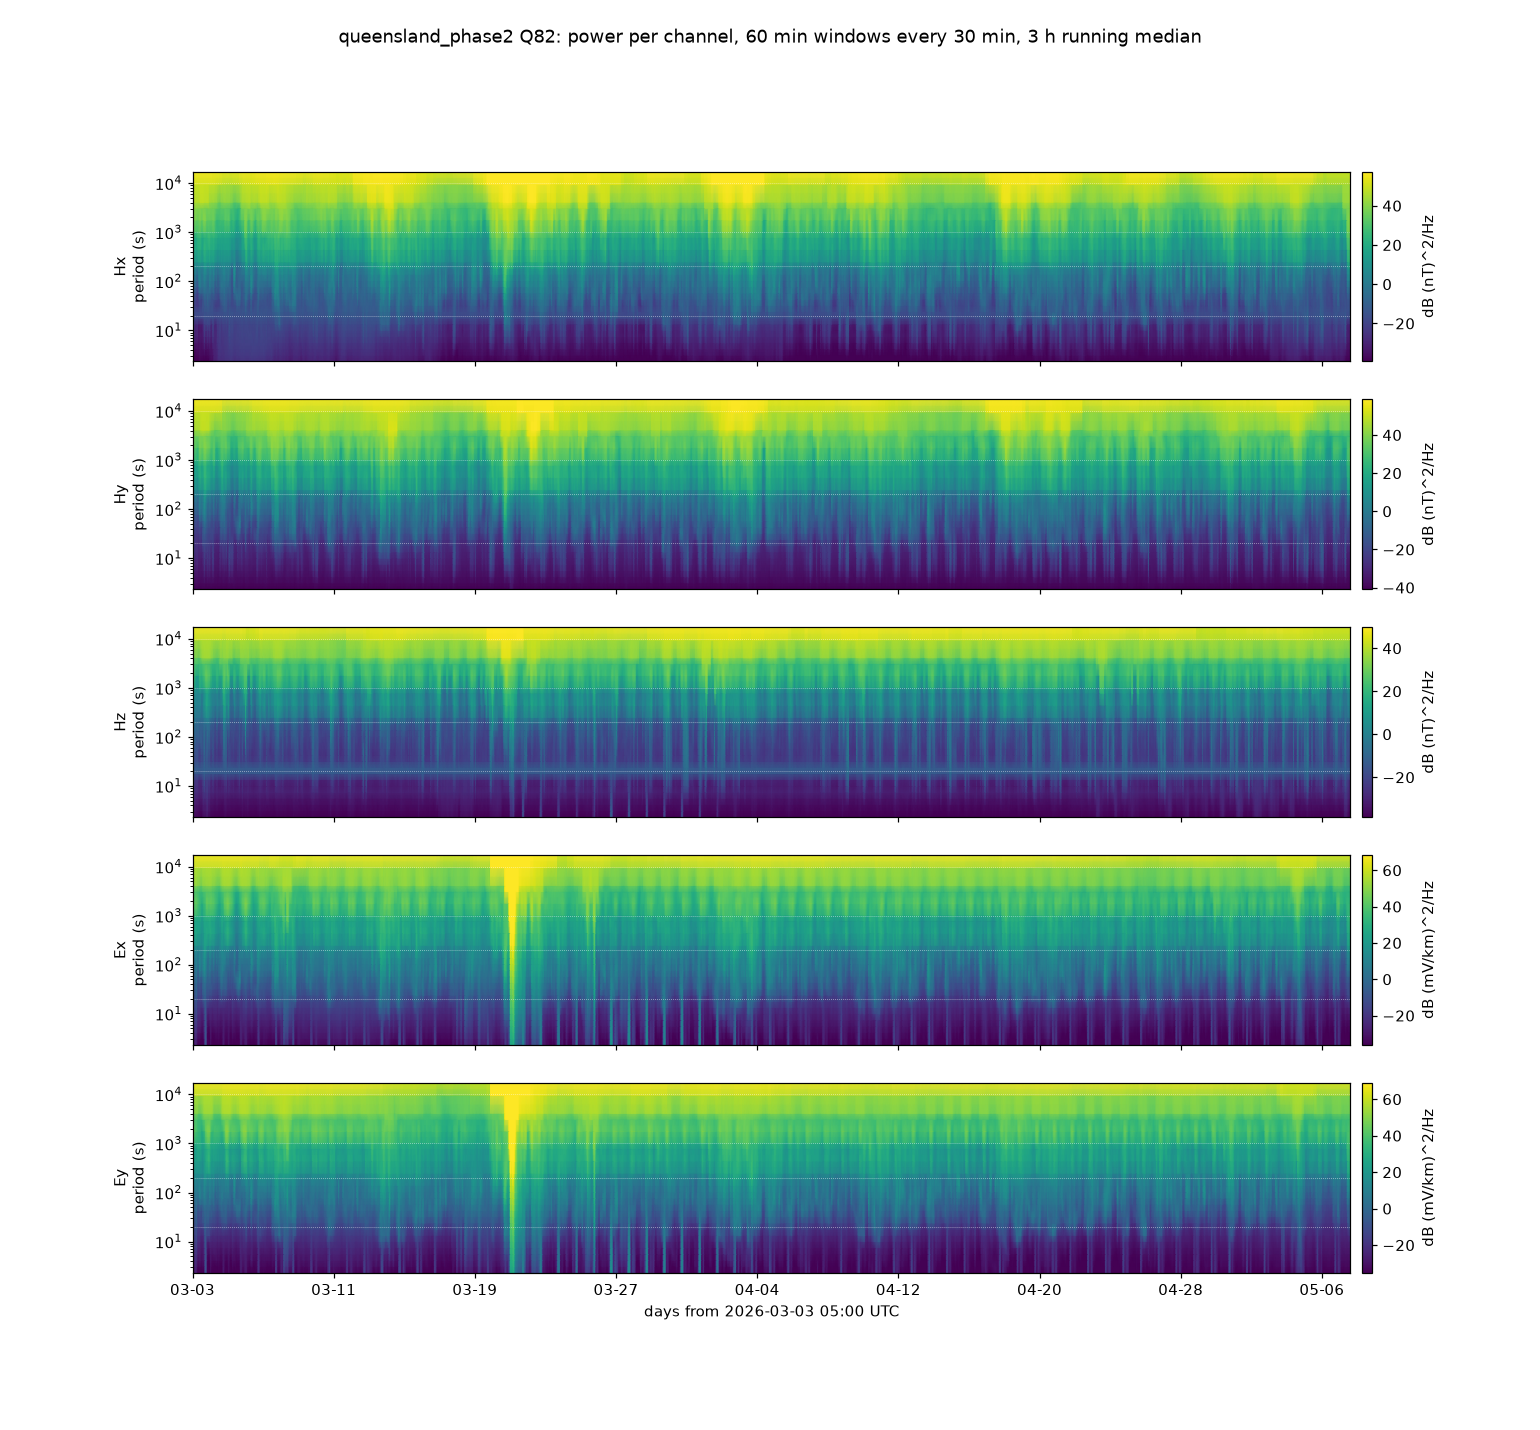

In [9]:
spec_rows = []
for s in CHOSEN:
    t = time.time()
    t0, arrays, meta, row = load(s)
    fig, pmaps = FSITE.spectrograms(t0, arrays, site_dir(s) / "05_spectrograms.png", fs=1.0,
                                    win_s=WIN_MIN * 60, step_s=STEP_MIN * 60, pmax=PMAX,
                                    title="%s %s: power per channel, %d min windows every %d min, %g h "
                                          "running median" % (sv.cfg["name"], s, WIN_MIN, STEP_MIN,
                                                              FSITE.SMOOTH_H))
    plt.close(fig)
    tab = FSITE.spectrogram_table(pmaps)
    tab.to_csv(site_dir(s) / "05_spectrograms.csv")
    WRITTEN += [site_dir(s) / "05_spectrograms.png", site_dir(s) / "05_spectrograms.csv"]
    for ch, r in tab.iterrows():
        spec_rows.append(dict(site=s, channel=ch, median_db=r["median dB at 20-200 s"],
                              frac_10db_below=r["windows 10 dB below"],
                              frac_10db_above=r["windows 10 dB above"], windows=r["windows"]))
    TIMING[s]["spectrogram_s"] = round(time.time() - t, 1)
    del arrays, pmaps
    print("%-9s %5.1f s  %s" % (s, TIMING[s]["spectrogram_s"],
                                " ".join("%s %.1f dB" % (r["channel"], r["median_db"])
                                         for r in spec_rows[-5:])), flush=True)

spect = pd.DataFrame(spec_rows)
print()
print("median power at 20-200 s (dB)")
print(spect.pivot(index="site", columns="channel", values="median_db").to_string())
print()
print("fraction of windows 10 dB below the median at 20-200 s")
print(spect.pivot(index="site", columns="channel", values="frac_10db_below").to_string())
show(SHOW_SITE, "05_spectrograms.png")


## The survey table

One row per site of what the five figures showed: the total field against IGRF and the flags the DC rule
fired, the fraction of scored days each electric line was sound, common-mode, dead or weak, and the median
power at 20-200 s per channel. It is written to `<work_root>/survey/records_summary.csv`, and it is what
workbook 03 reads when it chooses which sites and which days to process.

**This check fails if any site in the chosen set has no figure 01, 02, 03, 04 or 05 on disk.**

In [10]:
FIGS = ["01_record.png", "02_coherence_bands.png", "03_coherence_maps.png", "04_spectra.png",
        "05_spectrograms.png"]
db = spect.pivot(index="site", columns="channel", values="median_db")
summary = (dc.set_index("site")[["days", "F_over_Figrf", "H_over_Higrf", "Bz_over_Z", "angle_deg", "flags"]]
           .join(esum.set_index("site")[["days_scored", "Ex_sound_frac", "Ex_weak_frac", "Ex_common_frac",
                                         "Ex_dead_frac", "Ey_sound_frac", "Ey_weak_frac", "Ey_common_frac",
                                         "Ey_dead_frac", "both_sound_frac"]])
           .join(db.rename(columns=lambda c: "db_20_200_%s" % c)))
summary["figures_on_disk"] = [sum((WORK / s / f).exists() for f in FIGS) for s in summary.index]
summary = summary.reset_index()
out_csv = WORK / "survey" / "records_summary.csv"
out_csv.parent.mkdir(parents=True, exist_ok=True)
summary.to_csv(out_csv, index=False)
WRITTEN.append(out_csv)
print(summary.to_string(index=False))
print()
print("wrote %s (%d rows, %d columns)" % (out_csv, len(summary), len(summary.columns)))

short = summary[summary.figures_on_disk < len(FIGS)]
print()
if not len(summary):
    print("VERDICT: UNJUDGED -- the chosen set is empty, so no site was scored")
elif len(short):
    print("VERDICT: FAIL -- %d of %d sites are missing one of the five figures (%s)"
          % (len(short), len(summary),
             "; ".join("%s has %d of %d" % (r.site, r.figures_on_disk, len(FIGS))
                       for r in short.itertuples())))
else:
    print("VERDICT: PASS -- all %d sites carry all %d figures on disk (%d files), and the summary row of each "
          "is written" % (len(summary), len(FIGS), len(summary) * len(FIGS)))


site  days  F_over_Figrf  H_over_Higrf  Bz_over_Z  angle_deg                                flags  days_scored  Ex_sound_frac  Ex_weak_frac  Ex_common_frac  Ex_dead_frac  Ey_sound_frac  Ey_weak_frac  Ey_common_frac  Ey_dead_frac  both_sound_frac  db_20_200_Ex  db_20_200_Ey  db_20_200_Hx  db_20_200_Hy  db_20_200_Hz  figures_on_disk
 Q82 65.62        0.9919        1.0165     0.9831       0.09                                                66          0.818         0.136           0.045           0.0          0.803         0.152           0.045         0.000            0.758           6.3           7.0          -1.6          -4.1         -16.2                5
Q81N 65.79        0.9944        1.0239     0.9839     -10.46                                                66          1.000         0.000           0.000           0.0          1.000         0.000           0.000         0.000            1.000           9.8          12.7           1.2          -3.9          -4.9                5
Q

## What was written

In [11]:
rows = []
for p in sorted(set(WRITTEN)):
    p = Path(p)
    if p.exists():
        rows.append(dict(file=str(p), kb=round(p.stat().st_size / 1024, 1)))
for r in tuple(RATES):
    for s in CHOSEN:
        for suffix in (".npz", ".json"):
            p = WORK / ("cache_%dhz" % r) / (s + suffix)
            if p.exists():
                rows.append(dict(file=str(p), kb=round(p.stat().st_size / 1024, 1)))
files = pd.DataFrame(rows).drop_duplicates("file").sort_values("file")
print(files.to_string(index=False))
print()
print("%d files, %.1f MB" % (len(files), files.kb.sum() / 1024))
for r in tuple(RATES):
    d = WORK / ("cache_%dhz" % r)
    mb = sum(p.stat().st_size for p in d.glob("*.npz")) / 1024 ** 2 if d.exists() else 0.0
    print("cache_%dhz %.1f MB over %d files" % (r, mb, len(list(d.glob("*.npz"))) if d.exists() else 0))
print()
tm = pd.DataFrame(TIMING).T
tm["total_s"] = tm.sum(axis=1)
print("seconds per site")
print(tm.to_string())
print()
print("%d sites, %.1f minutes in all, %.1f s a site on average"
      % (len(tm), tm.total_s.sum() / 60.0, tm.total_s.mean()))


                                                                                 file        kb
         E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase2\Q58N\01_record.png     558.3
E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase2\Q58N\02_coherence_bands.png     331.6
 E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase2\Q58N\03_coherence_maps.png    1068.1
        E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase2\Q58N\04_spectra.png     128.6
   E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase2\Q58N\05_spectrograms.csv       0.2
   E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase2\Q58N\05_spectrograms.png    1278.2
                E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase2\Q58N\dc.csv       0.3
            E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase2\Q58N\elines.csv       5.3
         E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase2\Q59N\01_record.png     340.0
E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Pro